In [66]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [67]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [68]:
train_data = datasets.CIFAR10(root='/CIFAR_Data', train=True, transform=train_transform, download=True)

In [69]:
test_data = datasets.CIFAR10(root='/CIFAR_Data', train=False, transform=transform, download=True)

In [70]:
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [71]:
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.fc1 = nn.Linear(2*2*128, 120)
        self.fc2 = nn.Linear(120, 50)
        self.fc3 = nn.Linear(50, 10)

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.bn3(self.conv3(X)))
        X = F.max_pool2d(X, 2, 2)

        X = X.view(-1, 128*2*2)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

In [72]:
torch.manual_seed(41)
model = ConvolutionalNeuralNetwork()
model

ConvolutionalNeuralNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc1): Linear(in_features=512, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=10, bias=True)
)

In [73]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

In [74]:
import time 

epochs = 25
train_losses = []
test_losses = []
train_correct = []
test_correct = []

start_time = time.time()

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    for b, (X_train, y_train) in enumerate(train_loader):
        b += 1
        y_val = model(X_train)
        loss = criterion(y_val, y_train)

        predicted = torch.argmax(y_val.data, 1)
        batch_correct = (predicted == y_train).sum()
        trn_corr += batch_correct

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b % 100 == 0:
            print(f'Epoch: {i} loss: {loss.item()}')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            y_val = model(X_test)
            loss = criterion(y_val, y_test)

            predicted = torch.argmax(y_val.data, 1)
            batch_correct = (predicted == y_test).sum()
            tst_corr += batch_correct

        test_correct.append(tst_corr)
        test_losses.append(loss)

current_time = time.time()
total_time = current_time - start_time
print(f'the model took {total_time/60} minutes for training')

Epoch: 0 loss: 1.629033088684082
Epoch: 0 loss: 1.5048716068267822
Epoch: 0 loss: 1.331303358078003
Epoch: 0 loss: 1.3328927755355835
Epoch: 0 loss: 1.3346221446990967
Epoch: 0 loss: 1.1094504594802856
Epoch: 0 loss: 1.2351281642913818
Epoch: 1 loss: 1.3712940216064453
Epoch: 1 loss: 1.193900465965271
Epoch: 1 loss: 1.2998279333114624
Epoch: 1 loss: 0.9164783358573914
Epoch: 1 loss: 0.894391655921936
Epoch: 1 loss: 1.2345446348190308
Epoch: 1 loss: 1.1612335443496704
Epoch: 2 loss: 1.1460810899734497
Epoch: 2 loss: 1.0274567604064941
Epoch: 2 loss: 0.921891987323761
Epoch: 2 loss: 0.880063533782959
Epoch: 2 loss: 0.9646365642547607
Epoch: 2 loss: 0.8656527996063232
Epoch: 2 loss: 0.8578088283538818
Epoch: 3 loss: 0.9355154633522034
Epoch: 3 loss: 0.8518834114074707
Epoch: 3 loss: 1.1061407327651978
Epoch: 3 loss: 0.8863268494606018
Epoch: 3 loss: 1.0180517435073853
Epoch: 3 loss: 0.5640521049499512
Epoch: 3 loss: 0.8954207897186279
Epoch: 4 loss: 0.9029711484909058
Epoch: 4 loss: 1.121

In [75]:
Full_test_data = DataLoader(test_data, batch_size=10000, shuffle=False)

In [76]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in Full_test_data:
        y_pred = model(X_test)
        predicted = torch.argmax(y_pred, 1)
        correct += (predicted == y_test).sum()

In [77]:
correct.item()/len(test_data)*100

80.84

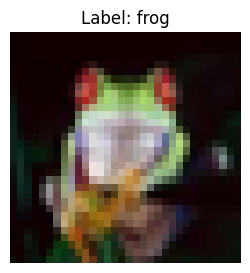

In [99]:
# 1. Fetch the first image and label
img, label = test_data[102]

# 2. Un-normalize
img = img / 2 + 0.5

# 3. Permute dimensions (C, H, W) -> (H, W, C)
img_permuted = img.permute(1, 2, 0)

# 4. Plot
plt.figure(figsize=(3, 3))
plt.imshow(img_permuted)
plt.title(f"Label: {train_data.classes[label]}")
plt.axis('off')
plt.show()

In [100]:
with torch.no_grad():
    model.eval()
    new_prediction = model(test_data[102][0].view(1,3,32,32))
new_prediction.argmax().item()

6

### Using Transfer learning

In [122]:
import torch.nn as nn
from torchvision import models

# 1. Load a pre-trained ResNet18 model with default ImageNet weights
new_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Freeze all pre-trained feature extraction layers
for param in new_model.parameters():
    param.requires_grad = False

# 3. Replace the final fully connected layer to match CIFAR-10 (10 classes)
# Note: 'requires_grad' is automatically True for this newly created layer
in_features = new_model.fc.in_features
new_model.fc = nn.Linear(in_features, 10)

# 4. Pass ONLY the trainable parameters to the optimizer (optional, but faster)
optimizer = torch.optim.Adam(new_model.fc.parameters(), lr=0.001)

In [123]:
from torchvision import models


transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Crop the original 32x32 image first
    transforms.RandomHorizontalFlip(),
    transforms.Resize(224),               # THEN resize to 224 for ResNet18
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [124]:
train_data = datasets.CIFAR10(root='/CIFAR_Data', train=True, transform=transform_train, download=True)
test_data = datasets.CIFAR10(root='/CIFAR_Data', train=False, transform=transform_test, download=True)


In [126]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

# Use a lower learning rate (e.g., 0.0003) so backprop doesn't shatter pre-trained weights
optimizer = torch.optim.Adam(new_model.parameters(), lr=0.0003)

new_model = new_model.to(device)
epochs = 10

for epoch in range(epochs):
    new_model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = new_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100.0 * correct / total
    print(f'Epoch [{epoch+1}/{epochs}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%')

KeyboardInterrupt: 

In [ ]:
with torch.no_grad():
    correct = 0
    total = 0
    for X_test, y_test in test_loader: # Swapped Full_test_data for test_loader
        X_test, y_test = X_test.to(device), y_test.to(device) # Send to device
        
        y_pred = new_model(X_test)
        predicted = torch.argmax(y_pred, 1)
        correct += (predicted == y_test).sum().item()
        total += y_test.size(0)

print(correct / total * 100)